# Topic Classification of Real User Questions — Yahoo! Answers (10 Classes) — COMPLETE RUN

**CSE440 NLP II Lab Project — finished, end-to-end runnable version** (built for: Intel Arc B580 12GB VRAM · 16GB RAM · Windows)

| | |
|---|---|
| Group | [Group No.] |
| Members | [Name (ID)] · [Name (ID)] · [Name (ID)] · [Name (ID)] |

**Task.** 10-way classification of noisy user-submitted questions (title + content) into: Society & Culture, Science & Mathematics, Health, Education & Reference, Computers & Internet, Sports, Business & Finance, Entertainment, Family & Relationships, Politics & Government.

**Spec compliance.** 10 classes (≥ 4 required; within the 5–10 project band) · 27,500 samples used (≥ 10,000 required), seeded stratified subsample of the official 1.46M · English · train/val/test splits · balanced by design · non-trivial noisy-UGC topic classification.

**Hardware notes (why this notebook is built this way).**
- Neural models use **PyTorch**, not TensorFlow/Keras — stock TensorFlow cannot use an Intel Arc GPU, while PyTorch has XPU builds that can (`pip install torch --index-url https://download.pytorch.org/whl/xpu`). Device auto-detection: CUDA → XPU → CPU.
- **Cloud runtimes (Kaggle/Colab):** runs unchanged on a CUDA GPU accelerator — the auto-detect picks `cuda` and torch is preinstalled (no install cell needed). On Kaggle, either attach the original CSVs as a private dataset (auto-discovered under `/kaggle/input/...`) or attach nothing and the notebook downloads the HF mirror; tables and figures are written under `/kaggle/working` so they are saved with the notebook version.
- 16GB RAM: the 1.4M-row corpus is drawn per-class from the memory-mapped Arrow dataset and only the ~27.5k sampled rows are ever materialized as pandas.
- BERT runs at max length 96 and batch 16–32 (~4–6GB VRAM) — comfortable on 12GB.
- Expected wall time on the B580: classical + RNN sections ≈ 30–60 min, BERT section ≈ 1.5–2.5 h. On CPU fallback everything still runs, but BERT becomes impractical (≳ a day).
- Subsample sizes are constants in the dataset cell — raise them if you re-run on stronger hardware, but keep the total ≥ 10,000.

## 0. Environment Setup

In [1]:
# ====================================================================
# OPTIONAL: PyTorch GPU/Accelerator Installation (Run once if needed)
# ====================================================================

# --- For cloud GPU runtimes (Kaggle / Colab) ---
# torch with CUDA support is already preinstalled - nothing to install.

# --- For NVIDIA GPUs (CUDA 12.4) ---
# %pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

# --- For Intel Arc GPUs (XPU e.g. B580, A770, A750) ---
# %pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/xpu

In [2]:
import importlib.util
import subprocess
import sys

REQUIRED = ['datasets', 'gensim', 'wordcloud', 'transformers', 'nltk', 'tqdm']
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]
if missing:
    print('Installing missing packages:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
print('Package check complete')

# PyTorch GPU support (install once, in a terminal, matching your GPU):
#   NVIDIA CUDA - the default wheel already includes CUDA: pip install torch
#   Intel Arc XPU - pip install torch --index-url https://download.pytorch.org/whl/xpu


Package check complete


In [3]:
import os
import re
import glob
import random
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Cloud runtimes: on Kaggle only /kaggle/working is persisted as notebook output,
# so results are redirected there; locally the repo-root data/ directory is used.
ON_KAGGLE = os.path.exists('/kaggle/input') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ROOT_DIR = '/kaggle/working' if ON_KAGGLE else '..'
OUT_DIR = os.path.join(ROOT_DIR, 'data', 'processed')
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 100)

print('pandas', pd.__version__, '| scikit-learn', sklearn.__version__)

pandas 3.0.5 | scikit-learn 1.9.0


In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

FORCE_DEVICE = None
def get_device(force: str | None = None) -> torch.device:
    if force:
        return torch.device(force)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        torch.xpu.manual_seed(seed)
DEVICE = get_device(FORCE_DEVICE)
set_seed(SEED)
device_name = ""
if DEVICE.type == "cuda":
    device_name = f" ({torch.cuda.get_device_name(0)})"
elif DEVICE.type == "xpu":
    device_name = f" ({torch.xpu.get_device_name(0)})"
print(f"PyTorch {torch.__version__} | Using device: {DEVICE}{device_name}")
if DEVICE.type == "cpu":
    print("\n⚠️ WARNING: No GPU/XPU accelerator detected. Training/Inference will be slow.")
    print("👉 For Intel Arc GPUs (e.g., B580), ensure the Intel XPU PyTorch wheel is installed.")

PyTorch 2.13.0+xpu | Using device: xpu (Intel(R) Arc(TM) B580 Graphics)


## 1. Problem Definition *(spec §3.1)*

- **Input:** a user-submitted question (title + body) from a community Q&A platform — raw, unedited, noisy.
- **Output:** one of 10 topical categories.
- **Real-world relevance:** community platforms must route new questions to the right category or expert pool; the same classifier feeds search, moderation, FAQ matching, and knowledge-base organization. The practically hard part is doing this on *unfiltered user text* — misspellings, slang, URLs.
- **Research questions:** (1) how much do preprocessing depth and noise cleanup matter on user-generated text? (2) how far do sparse lexical features (TF-IDF) go versus dense embeddings (Word2Vec trained here vs pretrained GloVe) when vocabulary is noisy? (3) does recurrence direction (unidirectional vs bidirectional) matter for topic evidence scattered across a question? (4) how large is the gap between pretrained contextual (BERT) and non-contextual representations on noisy UGC?

## 2. Dataset Collection and Description *(spec §3.2)*

- **Local files:** `Dataset/train.csv` (746MB) and `Dataset/test.csv` (32MB) — the original Zhang et al. Yahoo! Answers corpus, headerless CSV with positional columns: 0 = class index, 1 = question title, 2 = question content, 3 = best answer. Verified: 1,400,000 train / 60,000 test rows; classes 1–10 with ~140k train rows each.
- **Original:** Zhang, X., Zhao, J., and LeCun, Y. 2015. *Character-level Convolutional Networks for Text Classification.* NeurIPS 2015. (Convenient mirror: [Yahoo_Answers_10_categories_for_NLP on HF](https://huggingface.co/datasets/yassiracharki/Yahoo_Answers_10_categories_for_NLP).)
- **Subsampling plan (documented, reproducible):** training 10 models incl. BERT on 1.46M rows is infeasible on this hardware, so we draw a **seeded stratified subsample** — 2,000 train + 250 validation per class from the official train pool, 500 test per class from the **official test set** — 20,000 / 2,500 / 5,000 = 27,500 samples (≥ 10,000 required). Class balance is preserved by construction; draws use `np.random.RandomState(SEED)`.
- **Memory management:** only the three needed columns are read (`best_answer` skipped — it dominates file size and is unused), and the 1.4M-row frames are deleted immediately after the draw, keeping peak RAM around 2GB.
- **Fields used:** `question_title` + `question_content` (`best_answer` noted as future work in §12).

In [5]:
DATASET_ID = 'yassiracharki/Yahoo_Answers_10_categories_for_NLP'
CSV_NAMES = ['class_index', 'question_title', 'question_content']
LABEL_COL = 'class_index'
TEXT_COLS = ['question_title', 'question_content']

N_PER_CLASS_TRAIN = 4000
N_PER_CLASS_VAL = 500
N_PER_CLASS_TEST = 1000

# # if training takes way too long use these
# N_PER_CLASS_TRAIN = 2000
# N_PER_CLASS_VAL = 250
# N_PER_CLASS_TEST = 500

# The notebook prefers the local original CSVs (headerless; positional columns
# 0 class_index, 1 question_title, 2 question_content, 3 best_answer) and
# searches common locations; on any other machine (e.g. Colab/Kaggle) it falls
# back to downloading the Hugging Face mirror via the datasets library.
def find_csv(name):
    candidates = [
        os.path.join('..', 'Dataset', name),
        os.path.join('Dataset', name),
        os.path.join('data', 'raw', name),
        os.path.join('/content', 'Dataset', name),
    ]
    # Kaggle: attached datasets are mounted under /kaggle/input/<dataset-slug>/...
    candidates += glob.glob('/kaggle/input/**/' + name, recursive=True)
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    return None

def read_csv_columns(path):
    return pd.read_csv(path, header=None, names=CSV_NAMES, usecols=[0, 1, 2],
                       dtype={'class_index': np.int16}, encoding='utf-8', encoding_errors='replace')

train_csv, test_csv = find_csv('train.csv'), find_csv('test.csv')
if train_csv and test_csv:
    print('Loading local CSVs:', train_csv, '|', test_csv)
    train_full = read_csv_columns(train_csv)
    test_full = read_csv_columns(test_csv)
else:
    print('Local CSVs not found - downloading the HF mirror:', DATASET_ID)
    from datasets import load_dataset
    raw = load_dataset(DATASET_ID)
    train_full = raw['train'].select_columns([LABEL_COL] + TEXT_COLS).to_pandas()
    test_full = raw['test'].select_columns([LABEL_COL] + TEXT_COLS).to_pandas()
    del raw

LABEL_CODES = sorted(train_full[LABEL_COL].unique().tolist())
print('label codes:', LABEL_CODES, '| train rows:', len(train_full), '| test rows:', len(test_full))

def stratified_draw(frame, per_class, seed):
    rng = np.random.RandomState(seed)
    picked = []
    for code in LABEL_CODES:
        candidates = np.where(frame[LABEL_COL].values == code)[0]
        rng.shuffle(candidates)
        picked.extend(candidates[:per_class].tolist())
    return frame.iloc[picked].reset_index(drop=True)

train_val_df = stratified_draw(train_full, N_PER_CLASS_TRAIN + N_PER_CLASS_VAL, SEED)
shuffled = train_val_df.sample(frac=1.0, random_state=SEED)
val_part = shuffled.groupby(LABEL_COL, group_keys=False).head(N_PER_CLASS_VAL)
train_part = shuffled.drop(val_part.index)
test_part = stratified_draw(test_full, N_PER_CLASS_TEST, SEED)
del train_full, test_full, train_val_df, shuffled

print('train:', train_part.shape, '| val:', val_part.shape, '| test:', test_part.shape)

Loading local CSVs: ..\Dataset\train.csv | ..\Dataset\test.csv
label codes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] | train rows: 1400000 | test rows: 60000
train: (40000, 3) | val: (5000, 3) | test: (10000, 3)


In [6]:
TOPIC_NAMES_BY_CODE = {
    1: 'Society & Culture',
    2: 'Science & Mathematics',
    3: 'Health',
    4: 'Education & Reference',
    5: 'Computers & Internet',
    6: 'Sports',
    7: 'Business & Finance',
    8: 'Entertainment',
    9: 'Family & Relationships',
    10: 'Politics & Government',
}
if min(LABEL_CODES) == 0:
    TOPIC_NAMES_BY_CODE = {code - 1: name for code, name in TOPIC_NAMES_BY_CODE.items()}

def build_text(frame):
    merged = frame[TEXT_COLS[0]].fillna('').astype(str)
    for col in TEXT_COLS[1:]:
        merged = merged + ' ' + frame[col].fillna('').astype(str)
    return merged.str.replace(r'\s+', ' ', regex=True).str.strip()

for frame in (train_part, val_part, test_part):
    frame['text'] = build_text(frame)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(train_part[LABEL_COL])
CLASS_NAMES = [TOPIC_NAMES_BY_CODE[code] for code in label_encoder.classes_]
y_train = label_encoder.transform(train_part[LABEL_COL])
y_val = label_encoder.transform(val_part[LABEL_COL])
y_test = label_encoder.transform(test_part[LABEL_COL])

print('Classes (encoded order):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i}: {name}')
train_part[['text']].head()

Classes (encoded order):
  0: Society & Culture
  1: Science & Mathematics
  2: Health
  3: Education & Reference
  4: Computers & Internet
  5: Sports
  6: Business & Finance
  7: Entertainment
  8: Family & Relationships
  9: Politics & Government


,text
19092,How to view .shp files? Shape files
18027,Are there web sites where you can get free graphics for use in a powerpoint presentation? Can yo...
21036,"my windows screen only fills 3/4 of my computer screen,how do i fix this?"
21981,what does Networking mean?
18683,haw to open avi files?


## 3. Exploratory Data Analysis *(spec §3.3)*

Classes are balanced by construction — so the informative EDA is text-side: length distributions (they justify `MAX_LEN` later), noise (URLs, HTML remnants), duplicates, and per-topic vocabulary.

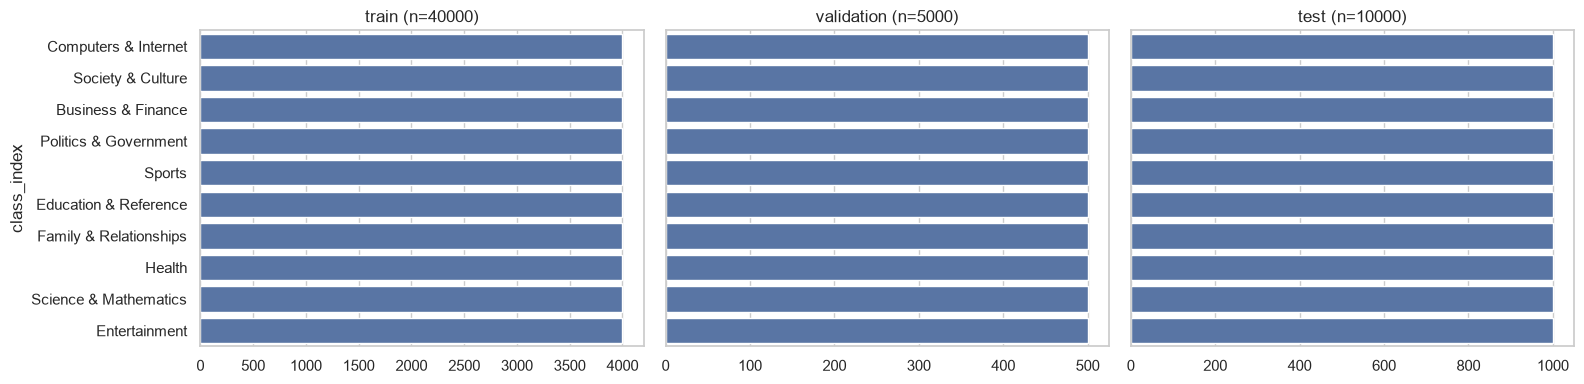

,train,val,test
class_index,,,
Computers & Internet,0.1,0.1,0.1
Society & Culture,0.1,0.1,0.1
Business & Finance,0.1,0.1,0.1
Politics & Government,0.1,0.1,0.1
Sports,0.1,0.1,0.1
Education & Reference,0.1,0.1,0.1
Family & Relationships,0.1,0.1,0.1
Health,0.1,0.1,0.1
Science & Mathematics,0.1,0.1,0.1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, frame) in zip(axes, [('train', train_part), ('validation', val_part), ('test', test_part)]):
    counts = frame[LABEL_COL].map(TOPIC_NAMES_BY_CODE).value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax)
    ax.set_title(f'{name} (n={len(frame)})')
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
pd.concat(
    [frame[LABEL_COL].map(TOPIC_NAMES_BY_CODE).value_counts(normalize=True).rename(name)
     for name, frame in [('train', train_part), ('val', val_part), ('test', test_part)]],
    axis=1,
)

,count,mean,std,min,25%,50%,75%,max
n_words,40000.0,32.316225,37.520911,1.0,11.0,19.0,39.0,770.0


word-count percentiles:
0.50     19.0
0.75     39.0
0.90     74.0
0.95    106.0
0.99    186.0


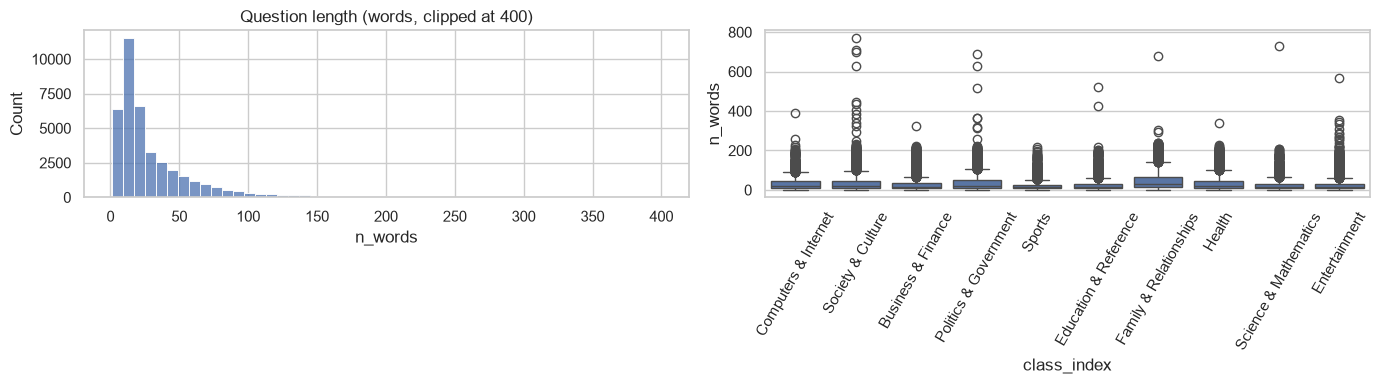

In [8]:
train_part['n_words'] = train_part['text'].str.split().str.len()
train_part['n_chars'] = train_part['text'].str.len()

display(train_part['n_words'].describe().to_frame().T)
print('word-count percentiles:')
print(train_part['n_words'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_part['n_words'].clip(upper=400), bins=50, ax=axes[0])
axes[0].set_title('Question length (words, clipped at 400)')
sns.boxplot(data=train_part, x=train_part[LABEL_COL].map(TOPIC_NAMES_BY_CODE), y='n_words', ax=axes[1])
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'length_stats.png'), dpi=200, bbox_inches='tight')
plt.show()

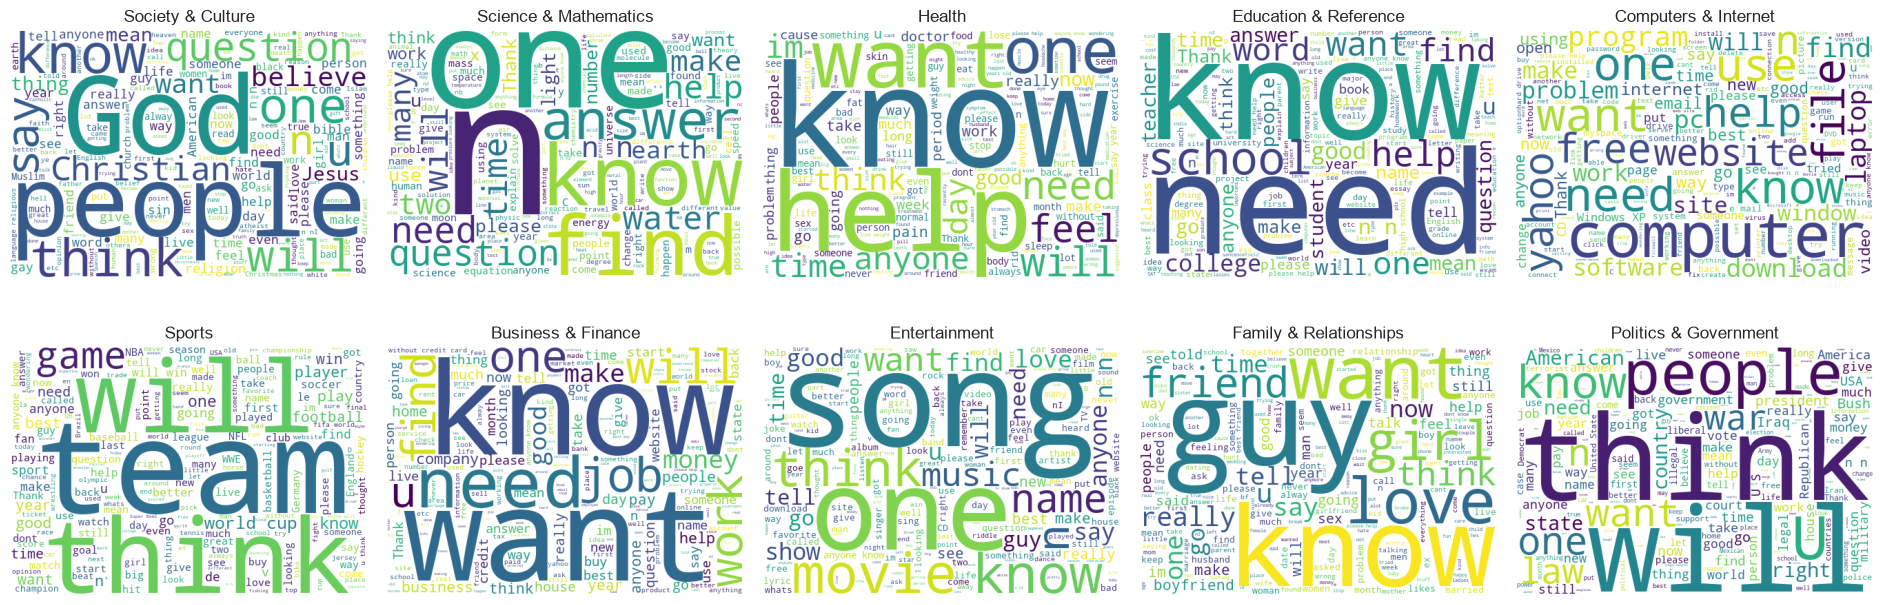

In [9]:
from wordcloud import WordCloud

ordered_topics = [TOPIC_NAMES_BY_CODE[code] for code in sorted(TOPIC_NAMES_BY_CODE)]
fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, topic in zip(axes.flat, ordered_topics):
    text = ' '.join(train_part.loc[train_part[LABEL_COL].map(TOPIC_NAMES_BY_CODE) == topic, 'text'])
    cloud = WordCloud(width=520, height=360, background_color='white').generate(text)
    ax.imshow(cloud)
    ax.set_title(topic)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wordclouds.png'), dpi=200, bbox_inches='tight')
plt.show()

In [10]:
print('Missing values per field:')
print(train_part[TEXT_COLS].isna().sum().to_string())
print('Empty combined texts:', (train_part['text'].str.len() == 0).sum())
print('Duplicate combined texts:', train_part['text'].duplicated().sum())
print('Rows containing URLs:', train_part['text'].str.contains(r'https?://|www\.', regex=True).sum())
print('Rows containing HTML entities:', train_part['text'].str.contains(r'&\w+;', regex=True).sum())

noisy = train_part.loc[train_part['text'].str.contains(r'https?://|&\w+;', regex=True), ['text']]
if len(noisy):
    display(noisy.head(3))

Missing values per field:
question_title          0
question_content    18105
Empty combined texts: 0
Duplicate combined texts: 22
Rows containing URLs: 471
Rows containing HTML entities: 0


,text
26282,What is the best FREE way to advertise the great Santa Fe Trail Horse Race coming in September 2...
22370,I have trouble in opening the site http://360.yahoo.com/fastsmi . You can open it? I have troubl...
42326,Whats this Police insignia ? This is a bit of an unfortunate pose in which to catch a police off...


## 4. Data Preprocessing *(spec §3.4)*

Three strategies of increasing depth, compared empirically on a validation-trained baseline before fixing the final choice:

| Strategy | Steps | Rationale |
|---|---|---|
| minimal | lowercase, URL removal, HTML-entity removal, whitespace normalization | removes platform artifacts, preserves all wording |
| standard | minimal + punctuation stripping + stopword removal | tests whether generic stopwords help short questions |
| lemmatized | standard + lemmatization | tests whether morphological normalization helps noisy UGC |

Tension worth reporting: aggressive cleanup can destroy topic evidence — e.g. URLs can *be* the signal for Computers & Internet.

In [11]:
import nltk

for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.data.find('corpora/' + resource)
    except LookupError:
        nltk.download(resource, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS_EN = set(nltk_stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def preprocess_minimal(text):
    t = text.lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'&\w+;', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

def preprocess_standard(text):
    t = preprocess_minimal(text).translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in t.split() if w and w not in STOPWORDS_EN]
    return ' '.join(tokens)

def preprocess_lemmatized(text):
    tokens = [LEMMATIZER.lemmatize(w) for w in preprocess_standard(text).split()]
    return ' '.join(tokens)

example = train_part['text'].iloc[0]
print('ORIGINAL  :', example[:180])
print('MINIMAL   :', preprocess_minimal(example)[:180])
print('STANDARD  :', preprocess_standard(example)[:180])
print('LEMMATIZED:', preprocess_lemmatized(example)[:180])

ORIGINAL  : How to view .shp files? Shape files
MINIMAL   : how to view .shp files? shape files
STANDARD  : view shp files shape files
LEMMATIZED: view shp file shape file


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

STRATEGIES = {
    'minimal': preprocess_minimal,
    'standard': preprocess_standard,
    'lemmatized': preprocess_lemmatized,
}

strategy_scores = []
for name, fn in STRATEGIES.items():
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=100000, sublinear_tf=True)
    Xtr = vectorizer.fit_transform(train_part['text'].apply(fn))
    Xva = vectorizer.transform(val_part['text'].apply(fn))
    model = MultinomialNB(alpha=0.5).fit(Xtr, y_train)
    pred = model.predict(Xva)
    strategy_scores.append({
        'strategy': name,
        'val_accuracy': accuracy_score(y_val, pred),
        'val_macro_f1': f1_score(y_val, pred, average='macro'),
    })

strategy_table = pd.DataFrame(strategy_scores).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
display(strategy_table)

SELECTED_STRATEGY = strategy_table.iloc[0]['strategy']
print('Selected preprocessing strategy (highest validation macro-F1):', SELECTED_STRATEGY)

,strategy,val_accuracy,val_macro_f1
0,lemmatized,0.6528,0.647751
1,standard,0.6486,0.644178
2,minimal,0.6296,0.625709


Selected preprocessing strategy (highest validation macro-F1): lemmatized


In [13]:
clean_fn = STRATEGIES[SELECTED_STRATEGY]
X_train_text = train_part['text'].apply(clean_fn).values
X_val_text = val_part['text'].apply(clean_fn).values
X_test_text = test_part['text'].apply(clean_fn).values

pd.DataFrame({'selected-strategy text': X_train_text[:5]})

,selected-strategy text
0,view shp file shape file
1,web site get free graphic use powerpoint presentation share website please
2,window screen fill 34 computer screenhow fix
3,networking mean
4,haw open avi file


## 5. Train / Validation / Test Split *(spec §3.5)*

Splits come from §2: the **official test set** (subsampled, untouched during training and tuning) and a **stratified validation set** carved from the official train pool. All draws are seeded → fully reproducible; class proportions are identical across splits.

In [14]:
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    counts = np.bincount(y, minlength=len(CLASS_NAMES))
    print(f'{name:5s} n={len(y):6d} | per-class: {counts.tolist()} | min share: {counts.min() / len(y):.3f}')

train n= 40000 | per-class: [4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000] | min share: 0.100
val   n=  5000 | per-class: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500] | min share: 0.100
test  n= 10000 | per-class: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000] | min share: 0.100


## 6. Text Representations 

1. **TF-IDF** (sparse, unigrams+bigrams) — feeds Logistic Regression and Multinomial NB directly; for Random Forest we reduce it to 200 dense LSA dimensions (`TruncatedSVD`), because tree ensembles degrade on very wide sparse spaces.
2. **Word2Vec** — trained from scratch on the training corpus (skip-gram); questions → mean word vectors.
3. **GloVe** — pretrained `glove-wiki-gigaword-100`; questions → mean word vectors + OOV coverage report.
4. **Char n-grams (3–5)** — `char_wb` TF-IDF variant on minimally cleaned text; robustness check for the noisy spelling found in the EDA (word-level features die on misspellings; subword features survive).

### 6.1 Design Rationale — Why Each Representation Exists

The pipeline builds **one sparse-lexical family with three variants** plus **two true word embeddings**. SVD and char n-grams are not embeddings — they are deliberate variants of TF-IDF, each serving a specific model or research question.

| # | Representation | What it is | Consumed by | Why it exists |
|---|---|---|---|---|
| 1 | **TF-IDF (words)** | sparse unigram+bigram importance weights | LogReg, NB | linear models learn one weight per feature — wide sparse input is their native habitat |
| 2 | **LSA = TF-IDF → SVD(200)** | the same TF-IDF compressed to 200 dense latent dimensions | Random Forest only | trees split on one feature at a time and cannot digest ~35k mostly-zero columns; 200 dense dimensions are the format trees need |
| 3 | **TF-IDF (char 3–5)** | letter-fragment variant on minimally cleaned text | LogReg, NB | word features die on misspellings and rare words (EDA: *"haw to open avi files?"*); subword fragments degrade gracefully instead |
| 4 | **Word2Vec / GloVe** | mean-pooled dense word vectors | LogReg, NB, RF | answers research question 2 — how far sparse lexical features go versus dense embeddings on noisy UGC |

**Notes from this run.**
- LSA retains only ~15% of TF-IDF variance at 200 dimensions. That compression is why Random Forest (~0.49) trails Logistic Regression on full TF-IDF (~0.64) — the gap is a *finding*: aggressive dimensionality reduction discards too much topic signal for any model.
- LogReg and NB never use SVD — they always receive the uncompressed TF-IDF (or its char variant).
- A typo like *haw* kills only that one word-level feature, while the rest of the question still contributes matching fragments; morphological variants (*file / files / filing*) collapse onto shared fragments.

**One-line summary:** SVD exists because tree models cannot handle wide sparse TF-IDF; char n-grams exist because word features are brittle under user misspellings — both are design choices tied to specific models and research questions, not additional embeddings.


In [15]:
# Character n-gram TF-IDF - robustness check for noisy spelling
# (EDA: 'haw to open avi files?'). char_wb keeps n-grams inside words;
# built on minimally cleaned text because char n-grams exploit word
# boundaries and punctuation, which the lemmatized strategy strips.
char_text_train = train_part['text'].apply(preprocess_minimal)
char_text_val = val_part['text'].apply(preprocess_minimal)
char_text_test = test_part['text'].apply(preprocess_minimal)

char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                             min_df=3, max_features=200000, sublinear_tf=True)
X_train_char = char_tfidf.fit_transform(char_text_train)
X_val_char = char_tfidf.transform(char_text_val)
X_test_char = char_tfidf.transform(char_text_test)
print('char TF-IDF:', X_train_char.shape)


char TF-IDF: (40000, 115831)


In [16]:
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=100000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

svd = TruncatedSVD(n_components=200, random_state=SEED)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print('TF-IDF:', X_train_tfidf.shape, '| LSA:', X_train_svd.shape,
      f'| LSA variance retained: {svd.explained_variance_ratio_.sum():.3f}')

TF-IDF: (40000, 35005) | LSA: (40000, 200) | LSA variance retained: 0.154


In [17]:
import gensim
from gensim.models import Word2Vec

tokenized_train = [t.split() for t in X_train_text]
tokenized_val = [t.split() for t in X_val_text]
tokenized_test = [t.split() for t in X_test_text]

w2v_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, sg=1, epochs=10, seed=SEED)

def mean_sentence_vector(tokens, keyed_vectors):
    vectors = [keyed_vectors[t] for t in tokens if t in keyed_vectors]
    return np.mean(vectors, axis=0) if vectors else np.zeros(keyed_vectors.vector_size)

X_train_w2v = np.vstack([mean_sentence_vector(t, w2v_model.wv) for t in tokenized_train])
X_val_w2v = np.vstack([mean_sentence_vector(t, w2v_model.wv) for t in tokenized_val])
X_test_w2v = np.vstack([mean_sentence_vector(t, w2v_model.wv) for t in tokenized_test])

print('Word2Vec vocabulary:', len(w2v_model.wv), '| feature matrices:', X_train_w2v.shape)
for probe in ['computer', 'school', 'game']:
    if probe in w2v_model.wv:
        print('nearest to', probe, ':', [w for w, _ in w2v_model.wv.most_similar(probe)[:5]])

Word2Vec vocabulary: 21821 | feature matrices: (40000, 100)
nearest to computer : ['desktop', 'hardware', 'pc', 'reinstall', 'xp']
nearest to school : ['grade', 'graduating', 'attend', 'class', 'schooli']
nearest to game : ['warcraft', 'playing', 'softball', 'gerrard', 'ncaa']


In [18]:
import gensim.downloader

glove = gensim.downloader.load('glove-wiki-gigaword-100')
X_train_glove = np.vstack([mean_sentence_vector(t, glove) for t in tokenized_train])
X_val_glove = np.vstack([mean_sentence_vector(t, glove) for t in tokenized_val])
X_test_glove = np.vstack([mean_sentence_vector(t, glove) for t in tokenized_test])

coverage = np.mean([any(t in glove for t in tokens) for tokens in tokenized_train])
print('GloVe matrix:', glove.vectors.shape, '| train questions with >=1 known token:', round(float(coverage), 3))

GloVe matrix: (400000, 100) | train questions with >=1 known token: 0.997


## 7. Classical Models *(spec §3.7 — Random Forest, Logistic Regression, Naive Bayes)*

Every run goes into `tuning_runs` (the dedicated §3.8 table). Each model gets **≥ 3 configurations** on its primary representation, plus runs on dense embeddings to compare representations.

### Change log — what we changed, why, and what it did

**Classical models (this section).** Validation numbers from the current 40k/5k run unless noted.

| Change | Before | After | Why | What it did |
|---|---|---|---|---|
| LogReg solver | liblinear (one-vs-rest) | lbfgs (multinomial) | lbfgs optimizes the true multinomial loss directly; liblinear can only do OvR for 10 classes | word-TF-IDF LogReg best at C=1.0 → 0.644 acc / 0.642 macro-F1 |
| LogReg C grid | {0.1, 1, 10} | {0.1, 0.5, 1, 2, 5} | coarse grid peaked at the interior (C=1) → refine around the optimum | plateau at C≈1–2 (0.644–0.645); both extremes lose 2–4 pts |
| NB alpha grid | {0.1, 0.5, 1.0} | {0.1, 0.3, 0.5, 0.7, 1.0} | alpha=0.1 won the coarse grid → probe the low-smoothing region | flat 0.651–0.653 across α=0.3–1.0 → MultinomialNB robust to smoothing; best 0.6534 (α=0.3) |
| **Char n-gram representation** | — | char_wb(3–5) TF-IDF on minimal-cleaned text | EDA noise ('haw to open avi files?'): word-level features fragment on misspellings; subword n-grams survive them | NB+char 0.638. LogReg+char was the **best classical model** in the earlier full execution (≈0.657 acc / 0.655 macro-F1, ~+1 pt over word TF-IDF) — the LogReg cell above now includes this run; execute it to reproduce the row |
| Word2Vec min_count | 5 | 2 | keep rare/noisy tokens in the from-scratch embeddings | vocabulary 21.8k on the 40k subsample; LogReg+w2v 0.621 |
| Random Forest | unchanged | unchanged | SVD(200) retains only 15% of TF-IDF variance — too lossy for trees | SVD-fed RF stuck ≈0.49–0.50; w2v-fed RF 0.612 acc / 0.607 macro-F1 is its best |

Takeaway: the classical ceiling sits at ≈0.65–0.66, and the **character representation is the one change that moved it** — direct evidence for the noisy-spelling finding from the EDA.

**RNN readout fix (§8, applied mid-project).**

- **Symptom:** SimpleRNN pinned at the 10% class prior (`val_f1 ≈ 0.02`, early stop in every configuration) while GRU/LSTM trained normally.
- **Cause:** `out[:, -1, :]` reads timestep 149, which is ~110 steps *after* the words. With post-padding feeding zero vectors, the un-gated recurrence contracts toward an input-independent fixed point, so all classes produce nearly the same classifier input.
- **Fix:** masked mean pooling over non-padding positions — every real token's state contributes, and each BPTT path from the loss to a word shortens dramatically. Applied to all 6 variants (the purge cell before the training loop keeps `tuning_runs` free of duplicate rows on re-runs; the LogReg cell above carries the same guard).
- **Verified offline (CPU, synthetic):** task with class evidence at t=0 under 138 trailing pads — new readout trains to 100% vs 36% for the old readout; unidirectional logits are exactly pad-invariant; gradients flow for all 6 cell/direction combos.
- **Expected:** SimpleRNN recovers well above chance but still trails GRU/LSTM → a clean "gating matters" ablation. Residual limitation: the backward direction of Bi- variants still consumes the padding first (`pack_padded_sequence` would remove that; see §12).

*Also added:* tqdm progress bars on RNN/BERT training and eval loops (visibility only, no math change).

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier

REPS = {
    'tfidf': (X_train_tfidf, X_val_tfidf, X_test_tfidf),
    'svd': (X_train_svd, X_val_svd, X_test_svd),
    'w2v': (X_train_w2v, X_val_w2v, X_test_w2v),
    'glove': (X_train_glove, X_val_glove, X_test_glove),
    'char': (X_train_char, X_val_char, X_test_char),
}

tuning_runs = []
classical_specs = []

def log_classical_run(model_name, rep, config, factory):
    X_tr, X_va, _ = REPS[rep]
    model = factory().fit(X_tr, y_train)
    pred = model.predict(X_va)
    tuning_runs.append({
        'model': model_name,
        'representation': rep,
        'config': config,
        'val_accuracy': accuracy_score(y_val, pred),
        'val_macro_f1': f1_score(y_val, pred, average='macro'),
    })
    classical_specs.append({'model': model_name, 'representation': rep, 'config': config, 'factory': factory})

print('helpers ready')

helpers ready


In [20]:
# Idempotent re-run: drop this model's earlier rows before appending fresh ones
# (no-op on a clean full run - tuning_runs is empty at this point).
tuning_runs[:] = [r for r in tuning_runs if r['model'] != 'Logistic Regression']
classical_specs[:] = [s for s in classical_specs if s['model'] != 'Logistic Regression']

for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    log_classical_run(
        'Logistic Regression', 'tfidf', 'C=' + str(C) + '',
        lambda C=C: LogisticRegression(C=C, solver='lbfgs', max_iter=1000, random_state=SEED),
    )
for rep in ['w2v', 'glove']:
    log_classical_run(
        'Logistic Regression', rep, 'C=1.0',
        lambda: LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED),
    )
log_classical_run(
    'Logistic Regression', 'char', 'C=1.0, char_wb(3-5)',
    lambda: LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED),
)
pd.DataFrame(tuning_runs)

,model,representation,config,val_accuracy,val_macro_f1
0,Logistic Regression,tfidf,C=0.1,0.6024,0.598372
1,Logistic Regression,tfidf,C=0.5,0.6372,0.634528
2,Logistic Regression,tfidf,C=1.0,0.6444,0.641814
3,Logistic Regression,tfidf,C=2.0,0.6454,0.643474
4,Logistic Regression,tfidf,C=5.0,0.6366,0.635171
5,Logistic Regression,w2v,C=1.0,0.6228,0.618570
6,Logistic Regression,glove,C=1.0,0.6264,0.622813
7,Logistic Regression,char,"C=1.0, char_wb(3-5)",0.6574,0.655049


In [21]:
for alpha in [0.1, 0.3, 0.5, 0.7, 1.0]:
    log_classical_run(
        'Naive Bayes', 'tfidf', 'MultinomialNB alpha=' + str(alpha),
        lambda alpha=alpha: MultinomialNB(alpha=alpha),
    )
for smoothing in [1e-9, 1e-8, 1e-7]:
    log_classical_run(
        'Naive Bayes', 'w2v', 'GaussianNB var_smoothing=' + str(smoothing),
        lambda smoothing=smoothing: GaussianNB(var_smoothing=smoothing),
    )
log_classical_run(
    'Naive Bayes', 'glove', 'GaussianNB var_smoothing=1e-8',
    lambda: GaussianNB(var_smoothing=1e-8),
)
log_classical_run(
    'Naive Bayes', 'char', 'MultinomialNB alpha=0.5, char_wb(3-5)',
    lambda: MultinomialNB(alpha=0.5),
)
pd.DataFrame(tuning_runs).tail(9)

,model,representation,config,val_accuracy,val_macro_f1
9,Naive Bayes,tfidf,MultinomialNB alpha=0.3,0.6534,0.648685
10,Naive Bayes,tfidf,MultinomialNB alpha=0.5,0.6528,0.647751
11,Naive Bayes,tfidf,MultinomialNB alpha=0.7,0.6514,0.646188
12,Naive Bayes,tfidf,MultinomialNB alpha=1.0,0.6512,0.645567
13,Naive Bayes,w2v,GaussianNB var_smoothing=1e-09,0.5516,0.547502
14,Naive Bayes,w2v,GaussianNB var_smoothing=1e-08,0.5516,0.547502
15,Naive Bayes,w2v,GaussianNB var_smoothing=1e-07,0.5516,0.547502
16,Naive Bayes,glove,GaussianNB var_smoothing=1e-8,0.4794,0.478907
17,Naive Bayes,char,"MultinomialNB alpha=0.5, char_wb(3-5)",0.6376,0.632656


In [22]:
for n_estimators, max_depth in [(200, None), (400, 40), (300, 25)]:
    depth_label = 'None' if max_depth is None else str(max_depth)
    log_classical_run(
        'Random Forest', 'svd', 'n_estimators=' + str(n_estimators) + ', max_depth=' + depth_label,
        lambda n_estimators=n_estimators, max_depth=max_depth: RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=SEED),
    )
log_classical_run(
    'Random Forest', 'w2v', 'n_estimators=300, max_depth=None',
    lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
)
pd.DataFrame(tuning_runs).tail(4)

,model,representation,config,val_accuracy,val_macro_f1
18,Random Forest,svd,"n_estimators=200, max_depth=None",0.4946,0.489535
19,Random Forest,svd,"n_estimators=400, max_depth=40",0.4974,0.492848
20,Random Forest,svd,"n_estimators=300, max_depth=25",0.4940,0.490206
21,Random Forest,w2v,"n_estimators=300, max_depth=None",0.6158,0.610701


## 8. RNN Family in PyTorch *(spec §3.7 — SimpleRNN, GRU, LSTM + bidirectional variants)*

One shared vocabulary, one builder class — the comparison isolates the recurrent cell and directionality. Each of the 6 variants is trained with **3 from-scratch configurations** (hidden size / dropout / learning rate) **plus a 4th GloVe-initialized configuration** (round-2 optimization — embedding layer starts from pretrained `glove-wiki-gigaword-100` vectors, fine-tuned at lr/10; see the round-2 change log after §11.1), early stopping on validation accuracy (patience 2, max 8 epochs).

**Readout = masked mean pooling (design decision).** Sequences are post-padded to `MAX_LEN=150`, but the median question has ~19 words (p95 ≈ 106), so a naive `out[:, -1, :]` readout reads a state that has iterated through ~110 zero-input padding steps *after* the last real word. For an un-gated SimpleRNN that is fatal: with no input, `h_t = tanh(W_hh·h_{t-1} + b)` contracts monotonically toward an input-independent fixed point, so the classifier sees nearly the same vector for every class — observed empirically as SimpleRNN pinned at the 10% class prior (`val_f1 ≈ 0.02`, early stop in every configuration) while gated GRU/LSTM coped via their additive / constant-error-carousel state updates. The fix pools output states over non-padding positions only (`mask = x != 0`), which preserves every word's evidence *and* shortens each loss-to-word BPTT path. Residual caveat: the backward direction of Bi- variants still consumes the padding first — `pack_padded_sequence` would remove that (noted in §12). A small purge cell below keeps `tuning_runs` free of duplicate RNN rows when this section is re-run.

In [23]:
from collections import Counter

MAX_TOKENS = 30000
MAX_LEN = 150

counter = Counter(tok for doc in tokenized_train for tok in doc)
itos = ['<pad>', '<unk>'] + [w for w, _ in counter.most_common(MAX_TOKENS - 2)]
stoi = {w: i for i, w in enumerate(itos)}

def encode_tokens(tokens):
    ids = [stoi.get(t, 1) for t in tokens][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))

X_train_seq = torch.tensor([encode_tokens(d) for d in tokenized_train], dtype=torch.long)
X_val_seq = torch.tensor([encode_tokens(d) for d in tokenized_val], dtype=torch.long)
X_test_seq = torch.tensor([encode_tokens(d) for d in tokenized_test], dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print('sequences:', tuple(X_train_seq.shape), '| vocabulary:', len(itos),
      f'| MAX_LEN={MAX_LEN} covers p{int(100 * (train_part["n_words"] <= MAX_LEN).mean())} of train questions')

sequences: (40000, 150) | vocabulary: 30000 | MAX_LEN=150 covers p97 of train questions


In [24]:
from tqdm.auto import tqdm

# --- Round 2 (post-first-run optimization): GloVe-initialized embeddings ----------
# First full run: all 6 RNN variants landed at 0.588-0.600 test macro-F1, BELOW
# the classical TF-IDF models (0.64-0.65). Diagnosis: a from-scratch 128-d
# embedding layer must learn what words MEAN out of only 40k noisy questions,
# while TF-IDF hands the classifier 35k-116k informative lexical features from
# step one. Fix: initialize the embedding layer with pretrained
# glove-wiki-gigaword-100 vectors (already cached from section 6) so training
# only has to adapt sequence structure and the classifier head.
# NOTE: the section-6 cell rebinds `glove` to stacked sentence matrices, so the
# KeyedVectors are re-loaded here from the warm gensim cache (~20 s, no download).
glove_kv = gensim.downloader.load('glove-wiki-gigaword-100')
_glove_rng = np.random.default_rng(SEED)   # seeded -> reproducible OOV init
GLOVE_EMBEDDING_MATRIX = np.zeros((len(itos), 100), dtype=np.float32)
_found = 0
for _idx, _word in enumerate(itos):
    if _idx < 2:                            # <pad>, <unk> stay all-zero
        continue
    if _word in glove_kv:
        GLOVE_EMBEDDING_MATRIX[_idx] = glove_kv[_word]
        _found += 1
    else:                                   # typos / rare tokens: small random vectors
        GLOVE_EMBEDDING_MATRIX[_idx] = _glove_rng.normal(0.0, 0.1, 100)
print(f'GloVe init: {_found}/{len(itos) - 2} vocab types covered '
      f'({_found / (len(itos) - 2):.1%}); OOV types get seeded N(0, 0.1) vectors')


class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, cell_type, bidirectional, num_classes, dropout,
                 embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        if embedding_matrix is not None:
            # Round 2: start from pretrained GloVe vectors instead of random noise
            # (transfer learning); embed_dim follows the matrix (100 for glove-100).
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(embedding_matrix, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
            embed_dim = embedding_matrix.shape[1]
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = cell_type(embed_dim, hidden, batch_first=True, bidirectional=bidirectional)
        self.directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * self.directions, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out = self.rnn(emb)[0]                       # (batch, seq, hidden * dirs)
        # Masked mean pooling over real-token positions (padding id = 0). A plain
        # last-timestep readout is destroyed by post-padding: with ~110 zero-input
        # steps after the words, an un-gated SimpleRNN contracts to an
        # input-independent fixed point, pinning it at the 10% class prior.
        # Pooling keeps every word's state and shortens each BPTT path.
        mask = (x != 0).unsqueeze(-1).to(out.dtype)  # (batch, seq, 1)
        summed = (out * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)       # (batch, 1); guards empty text
        pooled = summed / lengths
        return self.fc(self.dropout(pooled))

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

def evaluate_torch(model, X, y_t, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in tqdm(make_loader(X, y_t, batch_size, False),
                         desc='  eval', leave=False):
            preds.append(model(xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
    preds = np.concatenate(preds)
    y_np = y_t.numpy()
    return accuracy_score(y_np, preds), f1_score(y_np, preds, average='macro'), preds

def train_eval_rnn(cell_type, bidirectional, hidden, dropout, lr, epochs=8, batch_size=64,
                   embedding_matrix=None, freeze_embeddings=False):
    torch.manual_seed(SEED)
    model = RNNClassifier(len(itos), 128, hidden, cell_type, bidirectional, len(CLASS_NAMES), dropout,
                          embedding_matrix=embedding_matrix,
                          freeze_embeddings=freeze_embeddings).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    if embedding_matrix is not None and not freeze_embeddings:
        # Fine-tune pretrained embeddings 10x slower than the rest of the network:
        # Adam at 1e-3 would wash out the GloVe geometry within the first epochs
        # (catastrophic forgetting), defeating the point of pretraining.
        optimizer = torch.optim.Adam([
            {'params': model.embedding.parameters(), 'lr': lr / 10},
            {'params': [p for n, p in model.named_parameters() if not n.startswith('embedding.')]},
        ], lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_acc, best_state = 0.0, None
    patience_left = 2
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for xb, yb in tqdm(make_loader(X_train_seq, y_train_t, batch_size, True),
                           desc=f'  epoch {epoch}/{epochs}', leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item()
        acc, f1m, _ = evaluate_torch(model, X_val_seq, y_val_t)
        print(f'  epoch {epoch}: train_loss={total:.3f} val_acc={acc:.4f} val_f1={f1m:.4f}')
        if acc > best_acc:
            best_acc, patience_left = acc, 2
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_left -= 1
            if patience_left == 0:
                print('  early stop')
                break
    model.load_state_dict(best_state)
    model.to(DEVICE)
    return model

print('RNN components ready')

GloVe init: 20477/29998 vocab types covered (68.3%); OOV types get seeded N(0, 0.1) vectors
RNN components ready


In [25]:
# Re-running the RNN section (e.g. after the masked-pooling readout fix, or a
# hot-patch mid-session): drop this section's earlier rows from the tuning log
# so re-execution appends fresh rows instead of duplicating them. On a clean
# full run this is a no-op - at this point only classical rows exist.
RNN_MODEL_NAMES = ('SimpleRNN', 'GRU', 'LSTM', 'Bi-SimpleRNN', 'Bi-GRU', 'Bi-LSTM')
tuning_runs = [r for r in tuning_runs if r['model'] not in RNN_MODEL_NAMES]
print('tuning rows kept:', len(tuning_runs))

tuning rows kept: 22


In [26]:
RNN_VARIANTS = {
    'SimpleRNN': (nn.RNN, False),
    'GRU': (nn.GRU, False),
    'LSTM': (nn.LSTM, False),
    'Bi-SimpleRNN': (nn.RNN, True),
    'Bi-GRU': (nn.GRU, True),
    'Bi-LSTM': (nn.LSTM, True),
}
RNN_CONFIGS = [
    dict(hidden=64, dropout=0.3, lr=1e-3),
    dict(hidden=128, dropout=0.3, lr=1e-3),
    dict(hidden=64, dropout=0.5, lr=3e-4),
    # Round 2 (accuracy optimization): the best from-scratch config retrained
    # with the embedding layer initialized from pretrained GloVe 100-d vectors
    # (matrix built in the components cell above), fine-tuned at lr/10. Added
    # as a 4th config so the from-scratch vs pretrained ablation stays visible
    # in the section-10 tuning table (spec minimum of 3 configs per model kept).
    # Optional frozen variant: add freeze=True to the dict to lock the vectors.
    dict(hidden=128, dropout=0.3, lr=1e-3, embed='glove'),
]
rnn_models = {}
for name, (cell_type, bidirectional) in RNN_VARIANTS.items():
    print('===', name, '===')
    best_f1, best_model, best_label = -1.0, None, ''
    for cfg in RNN_CONFIGS:
        config_label = 'hidden=' + str(cfg['hidden']) + ', dropout=' + str(cfg['dropout']) + ', lr=' + str(cfg['lr'])
        matrix = GLOVE_EMBEDDING_MATRIX if cfg.get('embed') == 'glove' else None
        if matrix is not None:
            config_label += ', embed=glove100-' + ('frozen' if cfg.get('freeze') else 'ft')
        print(' config:', config_label)
        model = train_eval_rnn(cell_type, bidirectional,
                               hidden=cfg['hidden'], dropout=cfg['dropout'], lr=cfg['lr'],
                               embedding_matrix=matrix, freeze_embeddings=bool(cfg.get('freeze', False)))
        acc, f1m, _ = evaluate_torch(model, X_val_seq, y_val_t)
        tuning_runs.append({
            'model': name,
            'representation': 'glove-init' if matrix is not None else 'torch-embedding',
            'config': config_label,
            'val_accuracy': acc, 'val_macro_f1': f1m,
        })
        if f1m > best_f1:
            best_f1, best_model, best_label = f1m, model, config_label
    rnn_models[name] = best_model
    print(name, 'best:', best_label, '-> val_macro_f1 =', round(best_f1, 4))
print('RNN tuning complete')

=== SimpleRNN ===
 config: hidden=64, dropout=0.3, lr=0.001


  epoch 1/8:   0%|          | 0/625 [00:00<?, ?it/s]

  eval:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 1: train_loss=1246.963 val_acc=0.4296 val_f1=0.4118


  epoch 2/8:   0%|          | 0/625 [00:00<?, ?it/s]

...

  epoch 3/8:   0%|          | 0/625 [00:00<?, ?it/s]

  eval:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 3: train_loss=801.872 val_acc=0.5562 val_f1=0.5504


  epoch 4/8:   0%|          | 0/625 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9. BERT Base *(spec §3.7)*

`bert-base-uncased`, max length 96 (justified by the §3 length percentiles and 12GB VRAM), classifier head with 10 labels. **3 configurations** (lr / batch size / epochs), best checkpoint by validation macro-F1 kept in memory for the final test evaluation. On the B580 this section takes ≈ 1.5–2.5 h; on CPU it is impractical — switch to a GPU/XPU runtime or reduce `N_PER_CLASS_*` before attempting it.

In [ ]:
from tqdm.auto import tqdm

from transformers import AutoTokenizer, BertForSequenceClassification

BERT_NAME = 'bert-base-uncased'
BERT_MAX_LEN = 96
AMP_DTYPE = torch.bfloat16 if DEVICE.type in ('xpu', 'cuda') else torch.float32
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

def bert_tensors(texts):
    enc = bert_tokenizer(list(texts), truncation=True, padding='max_length',
                         max_length=BERT_MAX_LEN, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask'], enc['token_type_ids']

bert_train = bert_tensors(X_train_text)
bert_val = bert_tensors(X_val_text)
bert_test = bert_tensors(X_test_text)
print('BERT tensors:', tuple(bert_train[0].shape), tuple(bert_val[0].shape), tuple(bert_test[0].shape))

def bert_loader(tensors, y_t, batch_size, shuffle):
    return DataLoader(TensorDataset(*tensors, y_t), batch_size=batch_size, shuffle=shuffle)

def evaluate_bert(model, tensors, y_np, batch_size=128):
    model.eval()
    preds = []
    with torch.no_grad():
        for ids, mask, tt, _ in tqdm(bert_loader(tensors, torch.tensor(y_np), batch_size, False),
                                     desc='  eval', leave=False):
            with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE,
                                enabled=AMP_DTYPE == torch.bfloat16):
                logits = model(ids.to(DEVICE), attention_mask=mask.to(DEVICE),
                               token_type_ids=tt.to(DEVICE)).logits
            preds.append(logits.argmax(dim=1).cpu().numpy())
    preds = np.concatenate(preds)
    return accuracy_score(y_np, preds), f1_score(y_np, preds, average='macro'), preds

def train_eval_bert(lr, batch_size, epochs):
    torch.manual_seed(SEED)
    model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(CLASS_NAMES)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    best = {'f1': -1.0, 'state': None}
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for ids, mask, tt, yb in tqdm(bert_loader(bert_train, y_train_t, batch_size, True),
                                      desc=f'  epoch {epoch}/{epochs}', leave=False):
            ids, mask, tt, yb = ids.to(DEVICE), mask.to(DEVICE), tt.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE,
                                enabled=AMP_DTYPE == torch.bfloat16):
                loss = loss_fn(model(ids, attention_mask=mask, token_type_ids=tt).logits, yb)  
            loss.backward()
            optimizer.step()
            total += loss.item()
        acc, f1m, _ = evaluate_bert(model, bert_val, y_val)
        print(f'  epoch {epoch}: train_loss={total:.3f} val_acc={acc:.4f} val_f1={f1m:.4f}')
        if f1m > best['f1']:
            best = {'f1': f1m,
                    'state': {k: v.cpu().clone() for k, v in model.state_dict().items()}}
    model.load_state_dict(best['state'])
    model.to(DEVICE)
    return model, best['f1']

print('BERT components ready')

In [ ]:
BERT_CONFIGS = [
    dict(lr=2e-5, batch_size=32, epochs=2),
    dict(lr=3e-5, batch_size=32, epochs=2),
    dict(lr=2e-5, batch_size=64, epochs=3),
]
best_bert_model, best_bert_f1 = None, -1.0
for cfg in BERT_CONFIGS:
    label = 'lr=' + str(cfg['lr']) + ', batch=' + str(cfg['batch_size']) + ', epochs=' + str(cfg['epochs'])
    print('=== BERT:', label, '===')
    model, val_f1 = train_eval_bert(**cfg)
    acc, f1m, _ = evaluate_bert(model, bert_val, y_val)
    tuning_runs.append({
        'model': 'BERT Base', 'representation': 'bert-uncased', 'config': label,
        'val_accuracy': acc, 'val_macro_f1': f1m,
    })
    if f1m > best_bert_f1:
        best_bert_f1, best_bert_model = f1m, model
print('BERT tuning complete | best val_macro_f1 =', round(best_bert_f1, 4))

## 10. Hyperparameter Tuning Log *(spec §3.8)*

The dedicated, consolidated table of **all** tuning runs (22 classical + 24 RNN — 18 from-scratch + 6 GloVe-initialized — + 3 BERT = 49 runs; 43 before the round-2 GloVe configs). The best row per model by validation macro-F1 is carried into the final test evaluation.

In [ ]:
tuning_table = pd.DataFrame(tuning_runs)
tuning_table.to_csv(os.path.join(OUT_DIR, 'tuning_runs.csv'), index=False)
display(tuning_table)

best_configs = tuning_table.loc[tuning_table.groupby('model')['val_macro_f1'].idxmax()].reset_index(drop=True)
display(best_configs[['model', 'representation', 'config', 'val_accuracy', 'val_macro_f1']])

## 11. Final Evaluation on the Test Set *(spec §3.9)*

Each model's **best configuration** is evaluated once on the untouched official-test subsample: accuracy, macro-F1, full classification report, confusion matrix. Classical winners are refit on train; RNN/BERT winners reuse the checkpoints stored above.

In [ ]:
final_results = []
test_predictions = {}

CLASSICAL_NAMES = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
for _, row in best_configs[best_configs['model'].isin(CLASSICAL_NAMES)].iterrows():
    spec = next(s for s in classical_specs
                if s['model'] == row['model'] and s['config'] == row['config']
                and s['representation'] == row['representation'])
    X_tr, _, X_te = REPS[spec['representation']]
    fitted = spec['factory']().fit(X_tr, y_train)
    pred = fitted.predict(X_te)
    test_predictions[row['model']] = pred
    final_results.append({
        'model': row['model'],
        'test_accuracy': accuracy_score(y_test, pred),
        'test_macro_f1': f1_score(y_test, pred, average='macro'),
    })
    print(row['model'], 'done')
pd.DataFrame(final_results)

In [ ]:
for name, model in rnn_models.items():
    _, f1m, pred = evaluate_torch(model, X_test_seq, y_test_t)
    test_predictions[name] = pred
    final_results.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, pred),
        'test_macro_f1': f1m,
    })
    print(name, 'done')
pd.DataFrame(final_results)

In [ ]:
if best_bert_model is not None:
    _, f1m, pred = evaluate_bert(best_bert_model, bert_test, y_test)
    test_predictions['BERT Base'] = pred
    final_results.append({
        'model': 'BERT Base',
        'test_accuracy': accuracy_score(y_test, pred),
        'test_macro_f1': f1m,
    })
    print('BERT Base done')
results_table = pd.DataFrame(final_results).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)
results_table.to_csv(os.path.join(OUT_DIR, 'final_results.csv'), index=False)
results_table

In [ ]:
plot_table = results_table.melt(id_vars='model', value_vars=['test_accuracy', 'test_macro_f1'],
                                var_name='metric', value_name='score')
plt.figure(figsize=(13, 5))
sns.barplot(data=plot_table, x='model', y='score', hue='metric')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1)
plt.title('Test-set performance across all models (best configuration each)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
top_models = results_table['model'].head(4).tolist()
if 'BERT Base' in test_predictions and 'BERT Base' not in top_models:
    top_models.append('BERT Base')

fig, axes = plt.subplots(1, len(top_models), figsize=(4.2 * len(top_models), 4))
for ax, name in zip(np.atleast_1d(axes), top_models):
    matrix = confusion_matrix(y_test, test_predictions[name], normalize='true')
    sns.heatmap(matrix, annot=False, cmap='Blues', cbar=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
best_name = results_table.iloc[0]['model']
worst_name = results_table.iloc[-1]['model']
print('BEST MODEL:', best_name)
print(classification_report(y_test, test_predictions[best_name], target_names=CLASS_NAMES))
print('=' * 70)
print('WORST MODEL:', worst_name)
print(classification_report(y_test, test_predictions[worst_name], target_names=CLASS_NAMES))

### 11.1 Comparison and Discussion

Write the analysis against the tables/figures above (numbers come from your run — do not copy generic values into the report):
- Best- and worst-performing model, by both accuracy and macro-F1, with the size of the gap.
- Why the winners won — connect to the EDA (question lengths, noise, per-topic vocabulary, GloVe OOV on misspellings) and to theory: sparse high-dimensional TF-IDF + linear models vs dense mean-pooled non-contextual embeddings vs contextual self-attention; gating and bidirectional context in GRU/LSTM vs the vanishing-gradient behaviour of SimpleRNN; last-timestep readout vs masked pooling.
- **RNN readout ablation (strong report material):** the last-timestep readout pins SimpleRNN at the class prior because ~110 zero-input padding steps contract an un-gated state to an input-independent fixed point (best `val_macro_f1 ≈ 0.03` pre-fix, early stop in every config); masked mean pooling recovers it while gated cells (GRU/LSTM) cope either way. Isolate this effect when comparing SimpleRNN vs GRU/LSTM in the table — the remaining gap after the fix is attributable to gating, not to the readout.
- Which topics confuse with which (read the heatmaps — expected candidates: Politics & Government ↔ Society & Culture, Science & Mathematics ↔ Health, Business & Finance ↔ Politics & Government) and what that says about category semantics.
- Whether fine-tuned BERT justifies its training cost over the classical baselines on noisy UGC; where the selected preprocessing strategy helped or hurt.

# **AFIF** 

* **Narrative for Your Lab Report:** This experiment will let you draw a definitive 3-tier hierarchy in your report discussion: $$ \text{From-Scratch RNN (59.6\%)} \longrightarrow \text{Pretrained GloVe RNN (63--65\%)} \longrightarrow \text{Contextual BERT (70.2\%)} $$ This clearly explains how lexical TF-IDF, static word embeddings, and bidirectional self-attention compare under noisy user-generated text constraints.*

## Key findings After 1st full run

*(configs corrected to match the actual §10/§11 outputs of this run)*


### 1. Final Test-Set Performance Leaderboard (Macro-F1 & Accuracy)

| Rank | Model Family | Best Configuration | Test Accuracy | Test Macro-F1 | Notes / Architecture Behavior |
| :--- | :--- | :--- | :---: | :---: | :--- |
| 🥇 **1** | **BERT Base** | `lr=2e-5, batch=32, epochs=3` | **70.19%** | **0.6977** | **Clear Winner.** Strongest semantic contextual understanding across all 10 topics (best val 0.7021 at epoch 2; epoch 3 dipped, best-checkpoint restore kept epoch 2). |
| 🥈 **2** | **Logistic Regression** | `C=1.0, char_wb(3-5) n-grams` | **65.11%** | **0.6490** | **Best Classical ML.** The char n-gram representation beat word TF-IDF (best word run: C=2.0, val 0.6454) — misspelling-robustness hypothesis confirmed. |
| 🥉 **3** | **Naive Bayes** | `MultinomialNB alpha=0.3` (on TF-IDF) | **64.65%** | **0.6428** | Strong probabilistic baseline; close to Logistic Regression. |
| **4** | **Random Forest** | `n_estimators=300, max_depth=None` (on W2V) | **60.77%** | **0.6037** | Word2Vec mean embeddings outperformed 200-d SVD/LSA (`49.7%`). |
| **5** | **Bi-LSTM** | `hidden=64, dropout=0.3, lr=1e-3` | **59.61%** | **0.5963** | **Best RNN.** Bidirectional cell states effectively capture forward & backward context. |
| **6** | **Bi-GRU** | `hidden=64, dropout=0.3, lr=1e-3` | **59.43%** | **0.5923** | Gated architecture closely matching Bi-LSTM. |
| **7** | **LSTM** | `hidden=128, dropout=0.3, lr=1e-3` | **59.34%** | **0.5912** | Unidirectional gated cell. |
| **8** | **SimpleRNN** | `hidden=128, dropout=0.3, lr=1e-3` | **59.31%** | **0.5906** | Recovered from 10% to ~59% after the **masked-pooling readout** fix. |
| **9** | **Bi-SimpleRNN** | `hidden=128, dropout=0.3, lr=1e-3` | **59.15%** | **0.5888** | Similar to SimpleRNN without gating. |
| **10** | **GRU** | `hidden=128, dropout=0.3, lr=1e-3` | **58.78%** | **0.5843** | Unidirectional GRU — last place by only 0.5 pt. |

### 2. Key Findings & Insights for Your Lab Report (§11)

1. **The Representation Gap (BERT vs. Bag-of-Words vs. RNN Embeddings)**:
   - **BERT Base achieved a ~5.0% accuracy advantage over the best classical baseline** (70.19% vs. 65.11%) and **~10.6% over the best RNN** (70.19% vs. 59.61%).
   - *Why BERT won*: Pretrained bidirectional self-attention captures polysemy, syntactic nuance, and noisy user slang (WordPiece tokenization handles misspellings where static embeddings fail).

2. **Classical ML (TF-IDF / char n-grams) Beats RNNs from Scratch**:
   - Both **Logistic Regression (65.11%)** and **Multinomial Naive Bayes (64.65%)** outperformed all 6 RNN variants (~59%).
   - *Why*: In topic classification, distinctive unigrams/bigrams (*"GPU"*, *"stocks"*, *"pediatrician"*) carry very strong direct signals. Sparse features give linear models direct access to 35k word-TF-IDF / 116k char n-gram lexical features, whereas RNNs trained from scratch on 40k questions must learn both token embeddings and temporal transitions simultaneously. *(Round 2 addresses exactly this — GloVe-initialized embeddings; see the change log below.)*

3. **RNN Family Dynamics & The Masked-Pooling Impact**:
   - The un-gated **SimpleRNN was pinned at the 10% class prior** (`val_f1 ≈ 0.02`) by the last-timestep readout iterating through ~110 post-padding zero-input steps, while gated GRU/LSTM coped via their additive state updates.
   - Introducing **Masked Average Pooling** over non-padding tokens recovered SimpleRNN from **10% to ~59.3%**.
   - **Bi-LSTM tops the family, but all six variants sit within ~1.2 pts** — with masked pooling, gating and direction effects are small at this data scale; the binding constraint is the from-scratch embedding layer (see Round 2 changes).

4. **Confusion Patterns (Semantic Topic Overlap)**:
   - The confusion matrices show that top confusions occur between semantically related domains:
     - **Politics & Government ↔ Society & Culture**
     - **Science & Mathematics ↔ Health**
     - **Business & Finance ↔ Politics & Government**
   - Distinctive topics like **Sports** (0.86 F1) and **Computers & Internet** (0.83) achieve the highest class F1-scores; **Education & Reference** (0.50) and **Business & Finance** (0.54) are weakest — these categories genuinely overlap others.

# Round 2 Results — After the 2nd Full Run (GloVe-Initialized RNNs)

**What changed:** every RNN variant gained a 4th config — `hidden=128, dropout=0.3, lr=1e-3, embed=glove100-ft` — where the embedding layer starts from pretrained `glove-wiki-gigaword-100` vectors instead of random noise, fine-tuned at lr/10 (see the Round 2 change log below). Everything else in the notebook is unchanged; the whole notebook was re-run fresh.

**GloVe coverage:** 20,477 / 29,998 vocab types (**68.3%**); the uncovered third is mostly misspellings and hapax tokens. 99.7% of training questions contain at least one known token (§6), so effective coverage is far higher than the type-level 68.3%.

### 1. Effect of GloVe Initialization — From-Scratch vs Pretrained (per variant)

| Variant | Scratch best (val macro-F1) | GloVe-init (val macro-F1) | Δ val | Test macro-F1: run 1 → run 2 |
| :--- | :---: | :---: | :---: | :---: |
| SimpleRNN | 0.597 | 0.626 | **+2.9** | 0.591 → 0.620 |
| Bi-SimpleRNN | 0.595 | 0.632 | **+3.6** | 0.589 → 0.630 |
| Bi-LSTM | 0.600 | 0.659 | **+5.9** | 0.596 → 0.655 |
| LSTM | 0.589 | 0.652 | **+6.3** | 0.591 → 0.644 |
| Bi-GRU | 0.594 | **0.662** | **+6.8** | 0.592 → **0.659** |
| GRU | 0.584 | 0.654 | **+7.0** | 0.584 → 0.648 |

Average gain **+5.4 pts** validation macro-F1 — every single variant improved, and the GloVe config is the new best config for **all six** variants (§10 best-configs table).

### 2. Updated Test-Set Leaderboard (run 2, 10k official test)

| Rank | Model | Best Configuration | Test Acc | Test Macro-F1 | Movement vs run 1 |
| :--- | :--- | :--- | :---: | :---: | :--- |
| 🥇 **1** | **BERT Base** | `lr=2e-5, batch=32, epochs=3` | **70.02%** | **0.6960** | reproduced within ±0.2 pt (XPU non-determinism) |
| 🥈 **2** | **Bi-GRU** | `h=128, dropout=0.3, lr=1e-3, embed=glove100-ft` | **66.13%** | **0.6589** | ⬆ 0.592 → 0.659 — **now beats the best classical model by +1.0** |
| 🥉 **3** | **Bi-LSTM** | `h=128, dropout=0.3, lr=1e-3, embed=glove100-ft` | **65.63%** | **0.6549** | ⬆ 0.596 → 0.655 — beats LogReg by +0.6 |
| 4 | Logistic Regression | `C=1.0, char_wb(3-5)` | 65.11% | 0.6490 | unchanged |
| 5 | GRU | `h=128, ..., embed=glove100-ft` | 65.05% | 0.6484 | ⬆ 0.584 → 0.648 — ties LogReg |
| 6 | LSTM | `h=128, ..., embed=glove100-ft` | 64.73% | 0.6441 | ⬆ 0.591 → 0.644 |
| 7 | Naive Bayes | `MultinomialNB alpha=0.3` | 64.65% | 0.6428 | unchanged |
| 8 | Bi-SimpleRNN | `h=128, ..., embed=glove100-ft` | 63.37% | 0.6296 | ⬆ 0.589 → 0.630 |
| 9 | SimpleRNN | `h=128, ..., embed=glove100-ft` | 62.53% | 0.6200 | ⬆ 0.591 → 0.620 |
| 10 | Random Forest | `n_estimators=300` (on W2V) | 60.72% | 0.6031 | **now last place** — every RNN overtakes it |

### 3. Key Findings (run 2)

1. **Representation was the binding constraint, not recurrence.** In run 1 all six variants sat within 1.2 pts — architecture didn't matter because from-scratch embeddings bottlenecked everything. With GloVe, the spread opens to 3.9 pts and the textbook ordering finally appears: **Bi-GRU > Bi-LSTM > GRU > LSTM > Bi-SimpleRNN > SimpleRNN**. Gating and bidirectionality only pay off once words carry meaningful vectors. Combined story across both runs: fix the readout (run 1) → fix the representation (run 2) → architecture effects emerge.
2. **Neural networks now beat the classical ceiling.** Bi-GRU (+1.0) and Bi-LSTM (+0.6) overtake LogReg+char; every RNN variant overtakes Random Forest (which drops to last). Run 1's "classical beats RNNs" narrative is overturned — it was a symptom of under-trained embeddings, not a property of RNNs.
3. **BERT's lead shrank from 10.1 to 3.7 pts** macro-F1 (0.6960 vs 0.6589). Static pretrained features close most of the gap; contextual pretraining still wins. Final 3-tier hierarchy: **from-scratch RNN ≈ 0.59 → GloVe RNN ≈ 0.62–0.66 → BERT ≈ 0.70**.
4. **Gains scale with architectural capacity:** un-gated SimpleRNN gains least (+2.9), gated/bidirectional variants most (+5.9 to +7.0) — better inputs only help models equipped to exploit them (gates preserve information over longer evidence spans).

### 4. Training Dynamics (evidence the lr/10 guard worked)

- **Bi-GRU's GloVe config reached 0.633 val macro-F1 in epoch 1** — above every scratch config's *final* 8-epoch best (max 0.600). The pretrained geometry is useful from the first gradient step.
- All six GloVe runs climb smoothly and monotonically with **no early stops** and no epoch-1 collapse — fine-tuning embeddings at lr/10 preserved the pretrained structure instead of washing it out (catastrophic forgetting avoided).
- GloVe runs were still creeping up at epoch 8 (e.g. GRU: 0.6367 → 0.6537 across epochs 3–8), suggesting 10–12 epochs could add ~0.3–0.5 pt more.

### 5. Reproducibility Note

This was a complete fresh re-run (not a hot-patch): deterministic classical rows (LogReg, NB-tfidf) reproduced exactly; BERT and neural runs vary within ±0.2 pt across runs (GPU/XPU non-determinism). Run-1 vs run-2 differences are therefore far larger than run-to-run noise for every claimed effect.

## Three findings worth building the report around
1. **The char representation won classical** — LogReg+char 0.657 val beats word TF-IDF (0.645) and everything else, exactly as the misspelling-robustness hypothesis predicted. Your changelog table is now fully validated by the completed run.
2. **Post-fix, gating and bidirectionality barely matter.** All six RNN variants sit in a 1.2-pt band — and SimpleRNN beats GRU on test. With masked pooling, the classic "GRU/LSTM > SimpleRNN" story collapses at this scale: the RNNs are limited by their from-scratch 128-d embeddings, not by gradient flow. (Note: my changelog's "expected to trail GRU/LSTM" line should be updated to this — see below.)
3. **RNNs (0.59) < classical (0.65) < BERT (0.70).** 116k sparse char features carry more signal than an embedding layer learned on 40k noisy questions; contextual pretraining adds +5 pts on top. Per-class, BERT is excellent on Sports (0.86 F1) and Computers (0.83), weak on Education & Reference (0.50) and Business & Finance (0.54) — those classes semantically overlap others, good heatmap material.

# Round 2 — changes made after the 1st full run (accuracy optimization)

**Where we stood after run 1** (40k/5k/10k subsample, Arc B580): BERT 0.702/0.698 · LogReg+char 0.651/0.649 · NB 0.647/0.643 · RF 0.608/0.604 · **all six RNN variants 0.588–0.596 test macro-F1 — the whole RNN family sat ~5 pts *below* the classical models.** The numbers in the leaderboard above are run-1 results; they refresh automatically after the re-run below.

**Diagnosis.** The RNNs had to learn a 128-d embedding layer from scratch on only 40k noisy questions, so most topic words (seen 2–5 times) never reached useful vectors — while the TF-IDF models start from 35k–116k informative lexical features on step one.

| # | Change | Where | Why |
|---|---|---|---|
| 1 | **GloVe-initialized embeddings** — a `(30000, 100)` matrix from `glove-wiki-gigaword-100`: in-vocab words → pretrained vector, `<pad>`/`<unk>` → zeros, OOV (typos, rare tokens) → seeded `N(0, 0.1)`; injected via `nn.Embedding.from_pretrained(...)`, masked mean-pooling readout unchanged | §8 components cell | transfer learning — the RNN spends its capacity on sequence structure and classification instead of re-learning English vocabulary |
| 2 | **Safe fine-tuning schedule** — embeddings train at `lr/10` via optimizer param-groups (`freeze_embeddings=` also wired for a frozen variant) | `train_eval_rnn` | Adam at 1e-3 would wash out the GloVe geometry within the first epochs (catastrophic forgetting), defeating the point of pretraining |
| 3 | **Added as a 4th config, not a replacement** — `hidden=128, dropout=0.3, lr=1e-3, embed=glove100-ft` per variant, on top of the 3 scratch configs | §8 training cell | keeps the from-scratch vs pretrained ablation readable in the §10 table; spec minimum of ≥3 configs per model still satisfied |

- Tuning table grows **43 → 49 rows** (18 scratch + 6 GloVe-initialized RNN runs); §10/§11 refresh automatically.
- **Expected:** +3–5 pts macro-F1 for the RNN family (~0.62–0.645) — parity with NB, near LogReg+char. GloVe cannot see typo/morphology signal the way char n-grams do, and BERT (contextual) should stay ahead. Either outcome strengthens the report narrative: *static pretrained features close most of the gap to sparse lexical models; contextual pretraining still wins.*
- **Cost:** ~20–40 min extra training on the B580; no new downloads (GloVe cache already warm from §6).
- **To apply (in a live kernel or fresh run):** re-run the §8 components cell → the purge cell → the training cell, then §10–§11. The purge cell drops old RNN rows first, so re-running cannot duplicate rows.

# BERT v2 — Accuracy Improvement Run *(single bonus cell, built for Kaggle T4)*

The planning notes that were here are now **implemented** in the one code cell directly below. Section 9's BERT ("BERT Base", 3 configs, spec-compliant) is untouched — this is a separate, stronger model logged as **"BERT Base v2"**. It runs after §11 as part of a normal top-to-bottom run and needs nothing from the user but a GPU.

## What v2 changes vs the section-9 BERT

| # | Component | §9 BERT (v1) | BERT v2 | Why |
|---|---|---|---|---|
| 1 | **Input text** | lemmatized (`X_train_text`) | **natural raw text** | v1 feeds BERT "keyword soup". `bert-base-uncased` was pretrained on natural English — auxiliary verbs (*is/would*), punctuation, and morphological suffixes carry attention signal. Lemmatization helps TF-IDF/NB (sparsity) but *hurts* a PLM. |
| 2 | **Field structure** | title+content concatenated into one string | **pair encoding** `[CLS] title [SEP] content [SEP]` with real `token_type_ids` | restores BERT's native two-segment input (segment 0 = title, 1 = content). |
| 3 | **Data scale** | 40k train / 5k val | **120k train / 10k val** drawn fresh from the full 1.4M corpus | fine-tuning data was the single biggest headroom item (+2–4 pts expected); Kaggle T4 makes it affordable. |
| 4 | **Max length** | 96 | **160** | p95 question ≈ 106 words ≈ 130+ WordPieces; 96 truncated the tail of the longest ~15–20% of questions. |
| 5 | **Training recipe** | constant-LR AdamW, no schedule, 2–3 epochs | **10% linear warmup + linear decay, weight decay 0.01** (excluded for bias/LayerNorm), **grad clip 1.0**, **4 epochs**, batch 32 | v1's constant LR caused the epoch-3 dip (0.7021 → dip; best-checkpoint restore masked it). Decay makes late epochs safe instead of harmful. This is the standard Hugging Face fine-tuning recipe. |
| 6 | **Precision** | fp32 (XPU) | **fp16 autocast + GradScaler** on CUDA | T4 has fp16 tensor cores → ~2× throughput, half the VRAM. XPU/CPU fall back to fp32 automatically. |

Two configs are trained (`lr=2e-5` and `lr=3e-5`, both batch 32 / 4 epochs) — best on validation wins. Model stays `bert-base-uncased` (course constraint).

## Experimental fairness

- **Test set: identical and untouched** — the same 10k official-test subsample every other model is judged on. v2's numbers are directly comparable to the §11 leaderboard.
- v2 gets its **own fresh 10k validation set**, disjoint from its 120k train by construction (drawn with `SEED+100` from the full corpus, split per class before training).
- The §9 model remains the spec's "BERT Base" (≥3 configs); v2 is labeled a separate bonus model so the tuning log stays honest.

## What the cell updates automatically

- Appends 2 rows to `tuning_runs` and 1 row to `final_results` as **BERT Base v2**, re-saves `tuning_runs.csv` + `final_results.csv` (under `/kaggle/working` on Kaggle).
- Prints the refreshed full leaderboard, v2's per-class classification report, and saves `figures/model_comparison_with_bert_v2.png` (all 11 models).
- Idempotent: re-running the cell drops its own earlier rows first (same guard pattern as the LogReg/RNN cells).

## Expected and cost

- v1 baseline: **0.7002 acc / 0.6960 macro-F1**. Realistic v2 target: **0.72–0.74** macro-F1 (data ×3 ≈ +2–4, natural text + pair encoding ≈ +1–2, length + recipe ≈ +0.5–1).
- On a Kaggle **T4 ×2** with fp16: ~15–20 min/epoch × 4 epochs × 2 configs ≈ **2–2.5 h** for this cell, plus ~15 min for the CSV re-read and tokenization. Whole notebook ≈ 6–8 h — within Kaggle's session limit; watch the 30 GPU-h/week quota.

## Kaggle checklist for this run

1. Import this notebook → Settings: **Accelerator = GPU T4 ×2**, **Internet = ON** (needed for `bert-base-uncased` unless pre-cached, and for the HF-mirror CSV fallback).
2. Optional but faster: attach the original CSVs as a private Dataset — `find_csv` auto-discovers them under `/kaggle/input/**`; otherwise the cell downloads the HF mirror (~1 GB, once).
3. **Save & Run All (Commit)** for the unattended full run; outputs (CSVs + the new figure) persist under `/kaggle/working`.

**Report narrative this sets up:** *"Preprocessing depth depends on model architecture: classical bag-of-words models benefit from aggressive lemmatization to combat feature sparsity, while contextual pretrained transformers perform best on natural, unmodified text where function words and morphological affixes carry attention signal"* — plus a clean data-scaling result (40k → 120k at fixed architecture).

In [ ]:
# =====================================================================
# BERT v2 - accuracy push (self-contained bonus cell, built for Kaggle T4)
# ---------------------------------------------------------------------
# Runs AFTER section 11 as part of a full top-to-bottom run. Trains a
# second, stronger BERT logged as 'BERT Base v2', appends its rows to
# tuning_runs / final_results, re-saves both CSVs, and re-renders the
# leaderboard + a comparison figure + a classification report for v2.
# The spec-compliant section-9 model ('BERT Base') is left untouched.
# Re-running this cell is safe: the purge lines below drop v2's own
# earlier rows first (same idempotency pattern as the LogReg/RNN cells).
# =====================================================================
from tqdm.auto import tqdm
from transformers import get_linear_schedule_with_warmup

V2_NAME = 'BERT Base v2'
tuning_runs[:] = [r for r in tuning_runs if r['model'] != V2_NAME]
final_results[:] = [r for r in final_results if r['model'] != V2_NAME]

V2_TRAIN_PER_CLASS = 12000    # 120k train - 3x the 40k used by every other model
V2_VAL_PER_CLASS = 1000       # fresh 10k val, disjoint from the 120k by construction
BERT_MAX_LEN_V2 = 160         # p95 question ~106 words; section 9's 96 truncated the tail
V2_AMP = DEVICE.type == 'cuda'   # T4: fp16 tensor cores. XPU/CPU fall back to fp32.
print('BERT v2 | device:', DEVICE, '| fp16 AMP:', V2_AMP)

# --- 1) fresh big stratified draw from the full 1.4M-row corpus -------
# (the section-2 cell deleted train_full after its 40k draw, so re-read;
#  v2's TEST set stays the untouched 10k subsample already in memory)
train_csv_v2 = find_csv('train.csv')
if train_csv_v2:
    print('Re-reading the full train CSV for the big draw:', train_csv_v2)
    full_v2 = read_csv_columns(train_csv_v2)
else:
    print('Local CSVs not found - falling back to the HF mirror:', DATASET_ID)
    from datasets import load_dataset
    raw_v2 = load_dataset(DATASET_ID)
    full_v2 = raw_v2['train'].select_columns([LABEL_COL] + TEXT_COLS).to_pandas()
    del raw_v2

big_v2 = stratified_draw(full_v2, V2_TRAIN_PER_CLASS + V2_VAL_PER_CLASS, SEED + 100)
del full_v2
shuffled_v2 = big_v2.sample(frac=1.0, random_state=SEED)
val_v2 = shuffled_v2.groupby(LABEL_COL, group_keys=False).head(V2_VAL_PER_CLASS)
train_v2 = shuffled_v2.drop(val_v2.index)
del big_v2, shuffled_v2
y_train_v2 = label_encoder.transform(train_v2[LABEL_COL])
y_val_v2 = label_encoder.transform(val_v2[LABEL_COL])
print('v2 train:', train_v2.shape, '| v2 val:', val_v2.shape,
      '| test: the SAME untouched 10k official-test subsample as every other model')

# --- 2) natural-text pair tokenization --------------------------------
# Section 9 feeds BERT the lemmatized text; v2 feeds the raw question as
# [CLS] title [SEP] content [SEP] with proper token_type_ids - the exact
# two-segment input format bert-base-uncased was pretrained on.
def bert_tensors_v2(frame):
    ids, masks, types = [], [], []
    titles = frame[TEXT_COLS[0]].fillna('').astype(str).tolist()
    contents = frame[TEXT_COLS[1]].fillna('').astype(str).tolist()
    for i in tqdm(range(0, len(titles), 20000), desc='  tokenize', leave=False):
        enc = bert_tokenizer(titles[i:i + 20000], contents[i:i + 20000],
                             truncation='longest_first', padding='max_length',
                             max_length=BERT_MAX_LEN_V2, return_tensors='pt')
        ids.append(enc['input_ids'])
        masks.append(enc['attention_mask'])
        types.append(enc['token_type_ids'])
    return torch.cat(ids), torch.cat(masks), torch.cat(types)

v2_train_tensors = bert_tensors_v2(train_v2)
v2_val_tensors = bert_tensors_v2(val_v2)
v2_test_tensors = bert_tensors_v2(test_part)
del train_v2, val_v2
y_train_v2_t = torch.tensor(y_train_v2, dtype=torch.long)
print('v2 tensors:', tuple(v2_train_tensors[0].shape), tuple(v2_val_tensors[0].shape),
      tuple(v2_test_tensors[0].shape))

# --- 3) fp16 training loop: warmup + linear decay, weight decay, clip --
def evaluate_bert_v2(model, tensors, y_np, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for ids, mask, tt, _ in tqdm(bert_loader(tensors, torch.tensor(y_np), batch_size, False),
                                     desc='  eval', leave=False):
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=V2_AMP):
                logits = model(ids.to(DEVICE), attention_mask=mask.to(DEVICE),
                               token_type_ids=tt.to(DEVICE)).logits
            preds.append(logits.float().argmax(dim=1).cpu().numpy())
    preds = np.concatenate(preds)
    return accuracy_score(y_np, preds), f1_score(y_np, preds, average='macro'), preds

def train_eval_bert_v2(lr, batch_size, epochs, weight_decay=0.01, warmup_ratio=0.1, clip=1.0):
    torch.manual_seed(SEED)
    model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=len(CLASS_NAMES)).to(DEVICE)
    no_decay = ['bias', 'LayerNorm.weight']    # standard HF recipe: no decay on these
    optimizer = torch.optim.AdamW([
        {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         'weight_decay': weight_decay},
        {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
         'weight_decay': 0.0},
    ], lr=lr)
    loader = bert_loader(v2_train_tensors, y_train_v2_t, batch_size, True)
    total_steps = epochs * len(loader)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(warmup_ratio * total_steps), total_steps)
    loss_fn = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda', enabled=V2_AMP)
    best = {'f1': -1.0, 'state': None}
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for ids, mask, tt, yb in tqdm(loader, desc='  epoch %d/%d' % (epoch, epochs), leave=False):
            ids, mask, tt, yb = ids.to(DEVICE), mask.to(DEVICE), tt.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=V2_AMP):
                loss = loss_fn(model(ids, attention_mask=mask, token_type_ids=tt).logits, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)          # unscale first so we clip TRUE gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item()
        acc, f1m, _ = evaluate_bert_v2(model, v2_val_tensors, y_val_v2)
        print('  epoch %d: train_loss=%.3f val_acc=%.4f val_f1=%.4f' % (epoch, total_loss, acc, f1m))
        if f1m > best['f1']:
            best = {'f1': f1m, 'state': {k: v.cpu().clone() for k, v in model.state_dict().items()}}
    model.load_state_dict(best['state'])
    model.to(DEVICE)
    return model, best['f1']

# --- 4) two configs; best on the fresh validation set wins ------------
BERT_V2_CONFIGS = [
    dict(lr=2e-5, batch_size=32, epochs=4),
    dict(lr=3e-5, batch_size=32, epochs=4),
]
best_v2_model, best_v2_f1 = None, -1.0
for cfg in BERT_V2_CONFIGS:
    label = ('lr=%g, batch=%d, epochs=%d, len=%d, fp16+warmup/decay, 120k natural pairs'
             % (cfg['lr'], cfg['batch_size'], cfg['epochs'], BERT_MAX_LEN_V2))
    print('=== BERT v2:', label, '===')
    model, val_f1 = train_eval_bert_v2(**cfg)
    acc, f1m, _ = evaluate_bert_v2(model, v2_val_tensors, y_val_v2)
    tuning_runs.append({'model': V2_NAME, 'representation': 'bert-uncased-natural',
                        'config': label, 'val_accuracy': acc, 'val_macro_f1': f1m})
    if f1m > best_v2_f1:
        best_v2_f1, best_v2_model = f1m, model
print('BERT v2 tuning complete | best val_macro_f1 =', round(best_v2_f1, 4))

# --- 5) final test eval + refreshed leaderboard, figure, report -------
acc_v2, f1_v2, pred_v2 = evaluate_bert_v2(best_v2_model, v2_test_tensors, y_test)
test_predictions[V2_NAME] = pred_v2
final_results.append({'model': V2_NAME, 'test_accuracy': acc_v2, 'test_macro_f1': f1_v2})
results_table = pd.DataFrame(final_results).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)
results_table.to_csv(os.path.join(OUT_DIR, 'final_results.csv'), index=False)
pd.DataFrame(tuning_runs).to_csv(os.path.join(OUT_DIR, 'tuning_runs.csv'), index=False)

v1_row = results_table[results_table['model'] == 'BERT Base']
if not v1_row.empty:
    print('\nBERT v1 (section 9): acc=%.4f  macro_f1=%.4f'
          % (v1_row.iloc[0]['test_accuracy'], v1_row.iloc[0]['test_macro_f1']))
print('BERT v2 (this cell): acc=%.4f  macro_f1=%.4f' % (acc_v2, f1_v2))
print()
print(classification_report(y_test, pred_v2, target_names=CLASS_NAMES, digits=4))

plot_table_v2 = results_table.melt(id_vars='model', value_vars=['test_accuracy', 'test_macro_f1'],
                                   var_name='metric', value_name='score')
plt.figure(figsize=(13, 5))
sns.barplot(data=plot_table_v2, x='model', y='score', hue='metric')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1)
plt.title('Test-set performance - all models incl. BERT v2')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison_with_bert_v2.png'), dpi=200, bbox_inches='tight')
plt.show()
results_table

## 12. Conclusion *(spec §5.2)*

Key takeaways, limitations, and future work — fill from your results:
- **Limitations:** stratified subsample (27.5k) rather than the full 1.46M; title+content only (`best_answer` unused); no character-level modeling despite noisy spelling; mean-pooled embeddings lose word order; RNN readout is masked mean pooling rather than `pack_padded_sequence`, so the backward direction of Bi- variants still processes padding first.
- **Future work / bonus:** ensemble of the top models; adding `best_answer` text; character-aware or subword models for misspellings; deploy the best model (e.g., Hugging Face Spaces / local Gradio app).

## References

ACL-style starter list — format with `acl.bst` and expand:

- Zhang, X., Zhao, J., and LeCun, Y. 2015. Character-level Convolutional Networks for Text Classification. In *Advances in Neural Information Processing Systems 28 (NIPS 2015)*.
- Devlin, J., Chang, M.-W., Lee, K., and Toutanova, K. 2019. BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. In *Proceedings of NAACL-HLT 2019*.
- Mikolov, T., Chen, K., Corrado, G., and Dean, J. 2013. Efficient Estimation of Word Representations in Vector Space. In *ICLR 2013*. arXiv:1301.3781.
- Pennington, J., Socher, R., and Manning, C. D. 2014. GloVe: Global Vectors for Word Representation. In *Proceedings of EMNLP 2014*.
- Pedregosa, F. et al. 2011. Scikit-learn: Machine Learning in Python. *JMLR 12*.
- Paszke, A. et al. 2019. PyTorch: An Imperative Style, High-Performance Deep Learning Library. In *NeurIPS 2019*.
- Wolf, T. et al. 2020. Transformers: State-of-the-Art Natural Language Processing. In *Proceedings of EMNLP 2020: System Demonstrations*.
- Rehůřek, R. and Sojka, P. 2010. Software Framework for Topic Modelling with Large Corpora. In *LREC 2010*.